# Assignment pre-series04-python

### Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2 - Generate a known signal

### 1. Equation of a sinusoid:

$$
s(t) = A\sin(2\pi f t + \phi)
$$
We have: 

$$
f = frequency = 1 Hz
$$
$$
A = amplitude = 1
$$
$$
\phi = phase = 0
$$

So the equation that we will play with is:

$$
s(t) = \sin(2\pi t)
$$

### 2. Create a time vector

In [3]:
# Time vector
sampling_frequency = 100  # Hz
duration = 3              # seconds
n_samples = 100

time = np.linspace(0, duration, n_samples).reshape(-1, 1)# transform to column vector, -1 is used to automatically calculate 
# the number of rows based on the number of columns (1 in this case)

# Check the shape of the time vector
print("time.shape =", time.shape)

time.shape = (100, 1)


The time vector is now a column vector with 100 lines.

We used 100 samples instead of 1 000 samples as stated in the intructions. Indeed, later to plot the signal, a sample of 100 is used in the instructions. In order to get the same plots we used 100 samples.

### 3. Create a signal

We want to create a 2D array with the dimensions (x,y,z), with:

$$
f = frequency = 1 Hz
$$
$$
A = amplitude = 1
$$
$$
\phi = phase = \pi/4 = 0.25\pi
$$

For the phase, it will be apllied one time to y, and 2 times to z.

In [4]:
# Phase shift
phase_shift = 0.25 * np.pi

# Generate the three components
x = np.sin(2 * np.pi * 1 * time)
y = np.sin(2 * np.pi * 1 * time + phase_shift)
z = np.sin(2 * np.pi * 1 * time + 2 * phase_shift)

# Create the 2D signal array
signal = np.hstack((x, y, z))#hstack is used to concatenate the arrays horizontally (create one array with multiple columns)

# Check the shape of the signal array
print("signal.shape =", signal.shape)

signal.shape = (100, 3)


### 4. Plot the signals created

t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


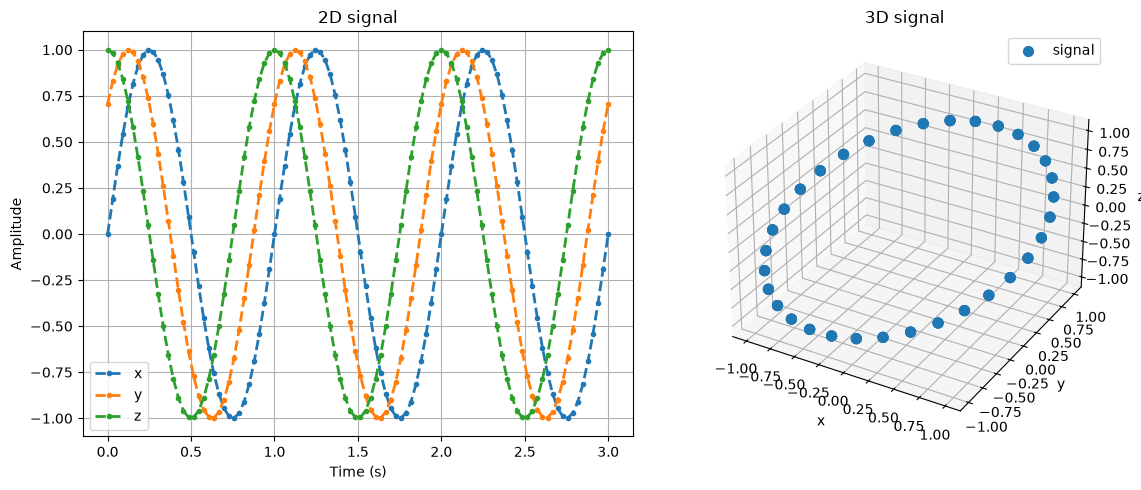

In [5]:
# Display the requested information
print("t.shape =", time.shape)
print("s.shape =", signal.shape)
print("phase_shift = 0.25 pi")

fig = plt.figure(figsize=(12, 5))

# 2D plot
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(time[:, 0], signal[:, 0], 'o--', markersize=3, linewidth=2, label='x')
ax1.plot(time[:, 0], signal[:, 1], 'o--', markersize=3, linewidth=2, label='y')
ax1.plot(time[:, 0], signal[:, 2], 'o--', markersize=3, linewidth=2, label='z')

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_title("2D signal")
ax1.legend()
ax1.grid()

# 3D plot
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.scatter(# to get a scatter plot
    signal[:, 0],
    signal[:, 1],
    signal[:, 2],
    s=50,
    label="signal"
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_title("3D signal")
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Estimate the time derivative of the signal

### 1. Maths formula

$$
s(t) = A\sin(2\pi f t+\phi)
$$

The time derivative is:

$$
\frac{ds(t)}{dt}=A\,2\pi f\cos(2\pi f t+\phi)
$$

For $A=1$, $f=1$ Hz and $\phi=0$:

$$
\frac{ds(t)}{dt}=2\pi\cos(2\pi t)
$$

### 2. Equation along each axis

The time derivative of signal along each axis is:

$$
\frac{dx(t)}{dt}=2\pi\cos(2\pi t)
$$

$$
\frac{dy(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{4}\right)
$$

$$
\frac{dz(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{2}\right)
$$

### 3. Difference between methods to compute time derivative of a signal

#### Forward difference:

The forward difference uses the current sample and the next sample to
approximate the time derivative:

$$
\frac{ds(t_i)}{dt}
\approx
\frac{s(t_{i+1})-s(t_i)}
{t_{i+1}-t_i}
$$

It uses information from the future sample only.


#### Central difference:

The central difference uses the previous and the next samples around
the current sample:

$$
\frac{ds(t_i)}{dt}
\approx
\frac{s(t_{i+1})-s(t_{i-1})}
{t_{i+1}-t_{i-1}}
$$

It uses information from both sides of the current sample.

#### Reference:
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html

### 4. Create 2 functions to compute the time derivative of a signal

Input order: First, signal is provided and then time. 

Signal is provided first because it is the quantity whose derivate is estimated. Time is provided second because the derivate is calculated with respect to time.

In [6]:
def forward_difference(signal, time):
    derivative = np.zeros_like(signal)#create an array of zeros with the same shape as the signal

    derivative[:-1, :] = (
        signal[1:, :] - signal[:-1, :]
    ) / (
        time[1:, :] - time[:-1, :]
    )

    derivative[-1, :] = derivative[-2, :]#for the last point, we can use the same value as the second to last point

    return derivative

In [7]:
def central_difference(signal, time):
    derivative = np.zeros_like(signal)

# Compute the central difference for the interior points
    derivative[1:-1, :] = (
        signal[2:, :] - signal[:-2, :]
    ) / (
        time[2:, :] - time[:-2, :]
    )

# Compute the forward difference for the first point
    derivative[0, :] = (
        signal[1, :] - signal[0, :]
    ) / (
        time[1, :] - time[0, :]
    )

# Compute the backward difference for the last point
    derivative[-1, :] = (
        signal[-1, :] - signal[-2, :]
    ) / (
        time[-1, :] - time[-2, :]
    )

    return derivative

In [8]:
# shape of the output

derivative_forward = forward_difference(signal, time)
derivative_central = central_difference(signal, time)

print("Signal shape:", signal.shape)
print("Forward derivative shape:", derivative_forward.shape)
print("Central derivative shape:", derivative_central.shape)

Signal shape: (100, 3)
Forward derivative shape: (100, 3)
Central derivative shape: (100, 3)


The output (forward and central derivate) has the same shape as the input signal.

### 5. Apply the functions to the signal and plot the result

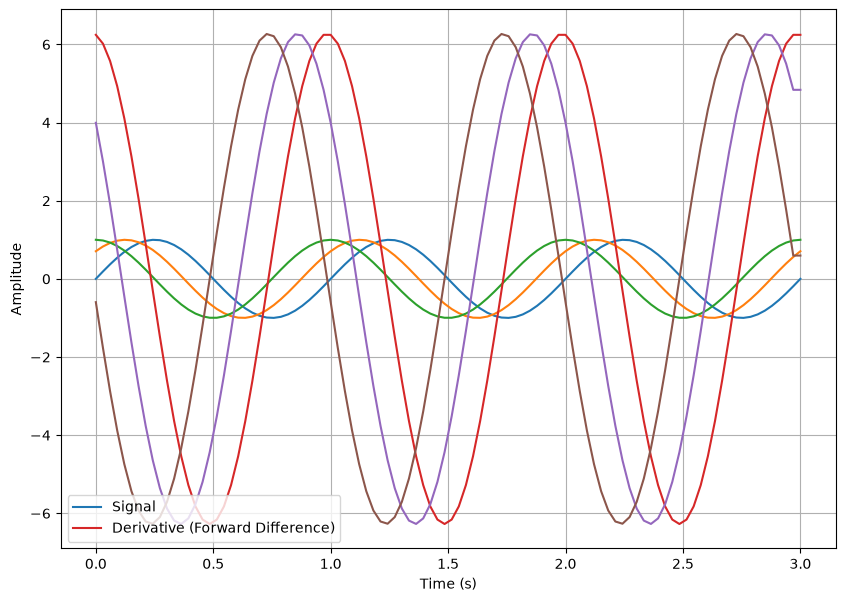

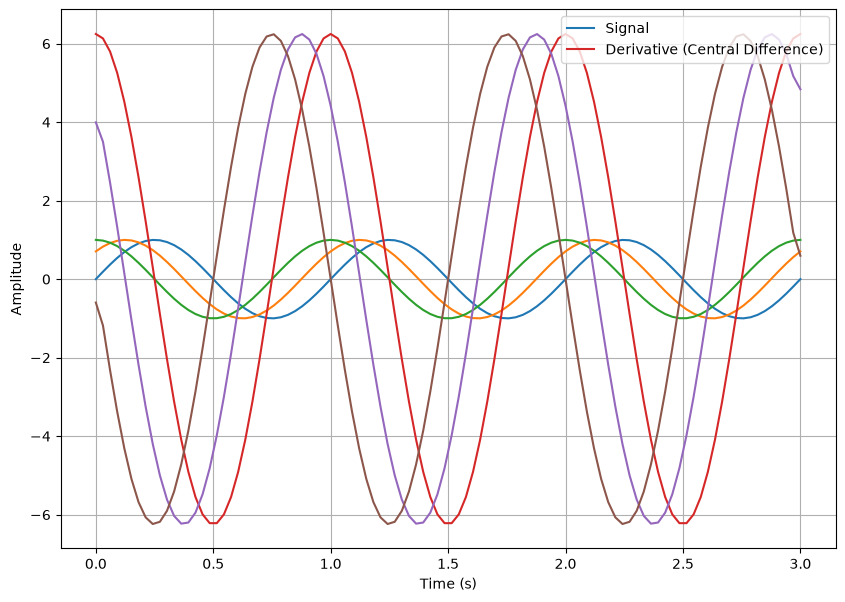

In [9]:
# Compute the derivatives
derivative_forward = forward_difference(signal, time)
derivative_central = central_difference(signal, time)

# ----- Forward difference -----
plt.figure(figsize=(10, 7))

# Signal x, y, z
plt.plot(time, signal[:, 0], label='Signal')
plt.plot(time, signal[:, 1])
plt.plot(time, signal[:, 2])

# Derivative x, y, z
plt.plot(time, derivative_forward[:, 0], label='Derivative (Forward Difference)')
plt.plot(time, derivative_forward[:, 1])
plt.plot(time, derivative_forward[:, 2])

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.show()


# ----- Central difference -----
plt.figure(figsize=(10, 7))

# Signal x, y, z
plt.plot(time, signal[:, 0], label='Signal')
plt.plot(time, signal[:, 1])
plt.plot(time, signal[:, 2])

# Derivative x, y, z
plt.plot(time, derivative_central[:, 0], label='Derivative (Central Difference)')
plt.plot(time, derivative_central[:, 1])
plt.plot(time, derivative_central[:, 2])

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.show()

Check the curves and the labels:

The 3 signals with an amplitude of 1 are the original signals.
The 3 signals with an amplitude of 6.28 (2pi) are the derivates.

The blue curve is the original signal x which has a phase of 0. 
The red curve corresponds to its derivative.

## 4. Estimate the tangential speed of the signal

### 1 Make clear the distinction between the tangential velocity and the tangential speed of a movement

#### Tangential velocity:

The tangential velocity is the time derivative of the position vector:

$$
\vec{v}(t) = \frac{d\vec{r}(t)}{dt}
$$

It is a vector, with one component along each axis:

$$
\vec{v}(t) = \left(\frac{dx(t)}{dt}, \frac{dy(t)}{dt}, \frac{dz(t)}{dt}\right)
$$

It is called tangential because, at each time t, this vector is tangent to the path of the movement.

#### Tangential speed:

The tangential speed is the magnitude (norm) of the tangential velocity:

$$
v(t) = \|\vec{v}(t)\|
$$

It is a scalar, always positive or zero. It tells how fast the point moves, but not in which direction.

#### Reference:
OpenStax, University Physics Volume 1, section 10.1 (tangential velocity and tangential speed, equation 10.4):
https://openstax.org/books/university-physics-volume-1/pages/10-1-rotational-variables

OpenStax, University Physics Volume 1, section 4.1 (velocity vector tangent to the path, equations 4.4 to 4.6, speed in Example 4.3):
https://openstax.org/books/university-physics-volume-1/pages/4-1-displacement-and-velocity-vectors

### 2. tangential speed of a 3D movement

The tangential velocity has one component along each axis:

$$
\vec{v}(t) = \left(\frac{dx(t)}{dt}, \frac{dy(t)}{dt}, \frac{dz(t)}{dt}\right)
$$

The tangential speed is the magnitude of this vector:

$$
v(t) = \sqrt{\left(\frac{dx(t)}{dt}\right)^2 + \left(\frac{dy(t)}{dt}\right)^2 + \left(\frac{dz(t)}{dt}\right)^2}
$$

#### Application to our signal:

From part 3, the derivatives along each axis are:

$$
\frac{dx(t)}{dt}=2\pi\cos(2\pi t), \quad
\frac{dy(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{4}\right), \quad
\frac{dz(t)}{dt}=2\pi\cos\left(2\pi t+\frac{\pi}{2}\right) = -2\pi\sin(2\pi t)
$$

So:

$$
v(t)^2 = 4\pi^2\left[\cos^2(2\pi t) + \sin^2(2\pi t) + \cos^2\left(2\pi t+\frac{\pi}{4}\right)\right]
$$

Since $\cos^2 + \sin^2 = 1$:

$$
v(t) = 2\pi\sqrt{1 + \cos^2\left(2\pi t+\frac{\pi}{4}\right)}
$$

The speed is not constant: it varies between $2\pi \approx 6.28$ and $2\pi\sqrt{2} \approx 8.89$.

### 3. Formula of the tangential speed of a nD movement

For a movement with n dimensions, the position is described by n coordinates $s_1(t), s_2(t), \dots, s_n(t)$.

The tangential velocity has one component along each dimension:

$$
\vec{v}(t) = \left(\frac{ds_1(t)}{dt}, \frac{ds_2(t)}{dt}, \dots, \frac{ds_n(t)}{dt}\right)
$$

The tangential speed is the magnitude of this vector:

$$
v(t) = \sqrt{\sum_{k=1}^{n} \left(\frac{ds_k(t)}{dt}\right)^2}
$$

Special cases:

For n = 1, the formula gives the absolute value of the derivative:

$$
v(t) = \left|\frac{ds_1(t)}{dt}\right|
$$

For n = 3, with $s_1 = x$, $s_2 = y$ and $s_3 = z$, we get the formula of the 3D movement.

### 4. Create a function to compute the tangential speed

The 4-D time series of the movement is made of 2 arrays: `signal`, with the 3 spatial dimensions (x, y, z) over columns, and `time`, with the measurement dates over rows.

Input order: First, signal is provided and then time.

Signal is provided first because it is the quantity whose tangential speed is computed. Time is provided second because the derivative is calculated with respect to time. This is the same order as the derivative functions of part 3.

The function works in 2 steps:
1. compute the tangential velocity with the central difference (one column per dimension)
2. compute the magnitude of the velocity for each sample, with the formula of section 4.3

In [10]:
def tangential_speed(signal, time):
    # Compute the tangential velocity (one column per dimension)
    velocity = central_difference(signal, time)

    # Compute the magnitude of the velocity for each sample
    # axis=1 sums over the dimensions (columns), keepdims=True keeps a column vector
    speed = np.sqrt(np.sum(velocity ** 2, axis=1, keepdims=True))

    return speed

In [11]:
# shape of the output

speed = tangential_speed(signal, time)

print("Signal shape:", signal.shape)
print("Speed shape:", speed.shape)

Signal shape: (100, 3)
Speed shape: (100, 1)


The output is a column vector with one value per sample: its shape is (N, 1), whatever the number of dimensions of the signal. The tangential speed is a scalar at each time, so the dimensions are reduced to 1 column.

### 5. Test the function with signals from 1D to nD

To know the expected output exactly, we use linear signals: $s_k(t) = a_k t$.
Their derivative is constant, $\frac{ds_k}{dt} = a_k$, and the finite difference of a linear function is exact (no approximation error).
So the expected tangential speed is constant:

$$
v = \sqrt{\sum_{k=1}^{n} a_k^2}
$$

We choose the coefficients so that the result is an integer:

| Test | Signal | Expected speed |
|---|---|---|
| 1D | $-3t$ | $\lvert -3 \rvert = 3$ |
| 2D | $(3t, 4t)$ | $\sqrt{9 + 16} = \sqrt{25} = 5$ |
| 3D | $(2t, 3t, 6t)$ | $\sqrt{4 + 9 + 36} = \sqrt{49} = 7$ |
| 4D | $(t, 2t, 2t, 4t)$ | $\sqrt{1 + 4 + 4 + 16} = \sqrt{25} = 5$ |
| nD (n = 9) | $(t, t, \dots, t)$ | $\sqrt{9 \times 1} = 3$ |
| 3D motionless | constant position | $0$ |

The 1D test checks that the speed is positive even if the derivative is negative.

We also test the sinusoidal signal of part 2, with the expected speed from section 4.2:

$$
v(t) = 2\pi\sqrt{1 + \cos^2\left(2\pi t+\frac{\pi}{4}\right)}
$$

The central difference is only an approximation for a sinusoid, so we compare the interior points with a tolerance of 0.1.

For each test, we also check that the output shape is (N, 1).

In [12]:
def test_tangential_speed():
    """Unit tests for tangential_speed function."""
    # Time vector used for all the linear tests: 11 samples from 0 to 1 s
    t = np.linspace(0, 1, 11).reshape(-1, 1)

    # Test 1: 1D linear signal s(t) = -3t
    # ds/dt = -3, so v = |-3| = 3
    s = -3 * t
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 3)

    # Test 2: 2D linear signal (3t, 4t)
    # v = sqrt(3^2 + 4^2) = sqrt(25) = 5
    s = np.hstack((3 * t, 4 * t))
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 5)

    # Test 3: 3D linear signal (2t, 3t, 6t)
    # v = sqrt(2^2 + 3^2 + 6^2) = sqrt(49) = 7
    s = np.hstack((2 * t, 3 * t, 6 * t))
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 7)

    # Test 4: 4D linear signal (1t, 2t, 2t, 4t)
    # v = sqrt(1^2 + 2^2 + 2^2 + 4^2) = sqrt(25) = 5
    s = np.hstack((1 * t, 2 * t, 2 * t, 4 * t))
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 5)

    # Test 5: nD linear signal with n = 9, every coordinate is 1t
    # v = sqrt(9 * 1^2) = sqrt(9) = 3
    s = np.hstack([t] * 9)
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 3)

    # Test 6: 3D motionless signal (constant position)
    # all derivatives are 0, so v = 0
    s = np.ones((11, 3))
    v = tangential_speed(s, t)
    assert v.shape == (11, 1)
    assert np.allclose(v, 0)

    # Test 7: 3D sinusoidal signal of part 2
    # v(t) = 2 pi sqrt(1 + cos^2(2 pi t + pi/4)) (section 4.2)
    # the central difference is an approximation, so we check the interior
    # points with a tolerance of 0.1
    v = tangential_speed(signal, time)
    v_expected = 2 * np.pi * np.sqrt(1 + np.cos(2 * np.pi * time + np.pi / 4) ** 2)
    assert v.shape == (100, 1)
    assert np.allclose(v[1:-1], v_expected[1:-1], atol=0.1)


# Testing the function
try:
    test_tangential_speed()
    print("All tests passed.")
except AssertionError:
    raise  # propagate the error

All tests passed.


## Part 5. Create an interactive plot with the plotly library

### 1. Install the plotly library

In [13]:
%pip install -q plotly

Note: you may need to restart the kernel to use updated packages.


### 2. Create a script that plots the signal and its tangential speed

We plot 4 curves on the same figure:
- the 3 axes of the signal: x, y and z (amplitude in m)
- the tangential speed (velocity in m/s), computed with `tangential_speed` from part 4

In [15]:
import plotly.graph_objects as go

# Tangential speed of the signal (function of part 4), shape (N, 1)
speed = tangential_speed(signal, time)

fig = go.Figure()

# One curve for each axis of the signal
for i, axis_name in enumerate(["x", "y", "z"]):
    fig.add_trace(go.Scatter(x=time[:, 0], y=signal[:, i], mode="lines", name=axis_name))

# Tangential speed
fig.add_trace(go.Scatter(x=time[:, 0], y=speed[:, 0], mode="lines", name="tangential speed"))

# Axis labels
fig.update_layout(
    xaxis_title="Time (s)",
    yaxis_title="Amplitude(m)/ Velocity(m/s)",
)

# scrollZoom allows us to zoom with the mouse wheel
#zoom_config = {"scrollZoom": True}

# Enable mouse-wheel zoom and keep the toolbar visible
plot_config = {"scrollZoom": True, "displayModeBar": True, "displaylogo": False}



fig.show(config=zoom_config)